# Reeling in Smart Attackers' Phishing Emails — Colab notebook

**CSE 587 — Group 5**: Parker Davis · Dillon VanGilder · Emmanuel Adjei Domfeh.

End-to-end pipeline (multi-seed, includes `char_perturb`):
1. Install dependencies
2. Clone the project from GitHub
3. (Optional) Mount Drive to back up checkpoints
4. Download the Champa et al.\ curated phishing dataset
5. Inspect the dataset
6. **Train baseline BERT — 3 seeds**
7. **Train BERT with smart-attacker augmentation — 3 seeds**
8. **Aggregate per-seed reports → mean ± std**
9. Visualize headline + per-edit ablation
10. Inspect smart-attacker examples

Runtime: **A100 GPU**. Total wall time ≈ 50–60 min for 3 baseline + 3 augmented runs.

## 1. Install dependencies

In [2]:
!pip install -q transformers==4.45.2 datasets==2.21.0 accelerate==0.34.2 \
    scikit-learn pandas matplotlib seaborn nltk requests pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 159.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 112.3 MB/s eta 0:00:00
ERROR: Operation cancelled by user


## 2. Clone the project from GitHub

In [3]:
!git clone https://github.com/eadomfeh1/cse587-phishing.git
%cd cse587-phishing

Cloning into 'cse587-phishing'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 53 (delta 15), reused 45 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 560.66 KiB | 40.05 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/cse587-phishing


In [4]:
import os, sys
sys.path.insert(0, os.getcwd())
print('CWD:', os.getcwd())
print('Files:', sorted(os.listdir('.')))

CWD: /content/cse587-phishing
Files: ['.git', '.gitignore', 'README.md', 'manuscript', 'notebooks', 'requirements.txt', 'scripts', 'src']


## 2b. (Optional) Back up results to Google Drive

Recommended: with 6 runs, you really want the checkpoints persisted somewhere if Colab disconnects.

In [5]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/cse587_results', exist_ok=True)

Mounted at /content/drive


## 3. Download the dataset

In [6]:
!python scripts/download_data.py
!ls -lh data/raw

Querying figshare metadata: https://api.figshare.com/v2/articles/24899952
  ↓ CEAS_08.csv from https://ndownloader.figshare.com/files/43817124
  ↓ Enron.csv from https://ndownloader.figshare.com/files/43817121
  ↓ Ling.csv from https://ndownloader.figshare.com/files/43817115
  ↓ SpamAssasin.csv from https://ndownloader.figshare.com/files/43817118
  ↓ TREC_05.csv from https://ndownloader.figshare.com/files/43817130
  ↓ TREC_06.csv from https://ndownloader.figshare.com/files/43817127
  ↓ TREC_07.csv from https://ndownloader.figshare.com/files/43817133
  ↓ Ceas-08_vectorized_data.csv from https://ndownloader.figshare.com/files/43826865
  ↓ Enron_vectorized_data.csv from https://ndownloader.figshare.com/files/43826862
  ↓ Ling_vectorized_data.csv from https://ndownloader.figshare.com/files/43826859
  ↓ SpamAssasin_vectorized_data.csv from https://ndownloader.figshare.com/files/43826856
  ↓ TREC-05_vectorized_data.csv from https://ndownloader.figshare.com/files/43826871
  ↓ TREC-06_vectoriz

## 4. Inspect the dataset

In [7]:
from src.data_loader import load_raw_csvs
df = load_raw_csvs()
print('Total rows:', len(df))
print(df.label.value_counts())
df.head(3)

Total rows: 131171
label
1    67230
0    63941
Name: count, dtype: int64


,subject,body,label,source
0,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,CEAS_08
1,Befriend Jenna Jameson,Upgrade your sex and pleasures with these tech...,1,CEAS_08
2,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,CEAS_08


## 5. Train baseline BERT — 3 seeds

Each run writes to `results/baseline_seed{N}/` (checkpoint, eval_report.json, report.md). Splits are cached in `data/processed/`, so the second and third runs reuse them and start training immediately.

In [8]:
for seed in (42, 123, 2024):
    print(f'\n===== BASELINE seed={seed} =====')
    !python -m src.train --model bert-base-uncased --epochs 3 --batch_size 64 --seed {seed}


===== BASELINE seed=42 =====
2026-04-27 18:14:34,284 [INFO] __main__: Device: cuda | model: bert-base-uncased | epochs=3 | bs=64 | lr=2e-05
2026-04-27 18:14:35,650 [WARNING] src.data_loader: Skipping Ceas-08_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 18:14:36,470 [WARNING] src.data_loader: Skipping Enron_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 18:14:36,590 [WARNING] src.data_loader: Skipping Ling_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 18:14:36,815 [WARNING] src.data_loader: Skipping SpamAssasin_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 18:14:37,619 [WARNING] src.data_loader: Skipping TREC-05_vectorized_data.csv — could not find text/label columns. Cols=['0', 'label']
2026-04-27 18:14:37,855 [WARNING] src.data_loader: Skipping TREC-06_vectorized_data.csv — could not find text/label columns. Cols=['0',

In [9]:
# Back up baseline runs to Drive (no-op if Drive isn't mounted)
!cp -r results /content/drive/MyDrive/cse587_results/baseline_3seeds_$(date +%Y%m%d_%H%M%S) 2>/dev/null && echo 'baseline runs saved to Drive' || echo 'Drive not mounted'

baseline runs saved to Drive


## 6. Train with smart-attacker augmentation — 3 seeds

Each run writes to `results/augmented_seed{N}/`. Same three seeds, with `--augment --augment_factor 1`. The default `aug_ops` now includes **`char_perturb`** (homoglyph + adjacent-letter swap) in addition to the previous four edits.

In [10]:
for seed in (42, 123, 2024):
    print(f'\n===== AUGMENTED seed={seed} =====')
    !python -m src.train --model bert-base-uncased --epochs 3 --augment --augment_factor 1 --batch_size 64 --seed {seed}


===== AUGMENTED seed=42 =====
2026-04-27 19:03:32,817 [INFO] __main__: Device: cuda | model: bert-base-uncased | epochs=3 | bs=64 | lr=2e-05
2026-04-27 19:03:32,818 [INFO] __main__: Reusing cached splits in /content/cse587-phishing/data/processed
2026-04-27 19:04:55,368 [INFO] __main__: Augmented training set: 104936 -> 158720 rows
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/content/cse587-phishing/src/train.py:140: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
2026-04-27 19:05:57,045 [INFO] __main__: Mixed precision enabled: bfloat16
/content/cse587-phishing/src/train.py:160: FutureWarning: `torch.cuda.

In [11]:
!cp -r results /content/drive/MyDrive/cse587_results/augmented_3seeds_$(date +%Y%m%d_%H%M%S) 2>/dev/null && echo 'augmented runs saved to Drive' || echo 'Drive not mounted'

augmented runs saved to Drive


## 7. Aggregate per-seed reports

Reads every `results/{baseline|augmented}_seed*/eval_report.json` and produces mean ± std for each metric, plus deltas, and a per-edit ablation table.

In [12]:
!python scripts/aggregate_seeds.py

Discovered runs:
  baseline: 3 seed(s) — [123, 2024, 42]
  augmented: 3 seed(s) — [123, 2024, 42]

Wrote /content/cse587-phishing/results/aggregated.json
Wrote /content/cse587-phishing/results/aggregated.md

# Multi-seed aggregated results

## Headline (mean ± std across seeds)

| Model | Standard F1 | Smart-attacker F1 | Standard acc | Smart-attacker acc |
|---|---|---|---|---|
| baseline (n=3) | 0.9958 ± 0.0002 | 0.9957 ± 0.0001 | 0.9957 ± 0.0002 | 0.9956 ± 0.0001 |
| augmented (n=3) | 0.9958 ± 0.0003 | 0.9977 ± 0.0001 | 0.9957 ± 0.0003 | 0.9976 ± 0.0001 |

## Effect sizes

- Baseline drop under attack: F1 0.9958 → 0.9957 = **-0.0000**
- Augmented drop under attack: F1 0.9958 → 0.9977 = **+0.0019**
- Augmentation effect on standard test: F1 0.9958 → 0.9958 = **+0.0000**
- Augmentation effect on smart-attacker test: F1 0.9957 → 0.9977 = **+0.0020**

## Per-edit ablation (augmented model, mean ± std)

| Edit | F1 (phishing) | Recall (phishing) |
|---|---|---|
| _none (standard test)_ |

In [13]:
# Display the markdown summary inline
from IPython.display import Markdown
Markdown(open('results/aggregated.md').read())

# Multi-seed aggregated results

## Headline (mean ± std across seeds)

| Model | Standard F1 | Smart-attacker F1 | Standard acc | Smart-attacker acc |
|---|---|---|---|---|
| baseline (n=3) | 0.9958 ± 0.0002 | 0.9957 ± 0.0001 | 0.9957 ± 0.0002 | 0.9956 ± 0.0001 |
| augmented (n=3) | 0.9958 ± 0.0003 | 0.9977 ± 0.0001 | 0.9957 ± 0.0003 | 0.9976 ± 0.0001 |

## Effect sizes

- Baseline drop under attack: F1 0.9958 → 0.9957 = **-0.0000**
- Augmented drop under attack: F1 0.9958 → 0.9977 = **+0.0019**
- Augmentation effect on standard test: F1 0.9958 → 0.9958 = **+0.0000**
- Augmentation effect on smart-attacker test: F1 0.9957 → 0.9977 = **+0.0020**

## Per-edit ablation (augmented model, mean ± std)

| Edit | F1 (phishing) | Recall (phishing) |
|---|---|---|
| _none (standard test)_ | 0.9958 ± 0.0003 | 0.9957 ± 0.0006 |
| `char_perturb` | 0.9975 ± 0.0001 | 0.9992 ± 0.0001 |
| `mask_urls` | 0.9963 ± 0.0001 | 0.9966 ± 0.0004 |
| `remove_urgency` | 0.9958 ± 0.0004 | 0.9957 ± 0.0008 |
| `rewrite_subject` | 0.9958 ± 0.0003 | 0.9956 ± 0.0007 |
| `synonym_swap` | 0.9964 ± 0.0002 | 0.9968 ± 0.0002 |
| _all combined (smart test)_ | 0.9977 ± 0.0001 | 0.9995 ± 0.0002 |

## Seeds in this aggregation

- **baseline**: seeds [123, 2024, 42]
- **augmented**: seeds [123, 2024, 42]


## 8. Visualize: headline + per-edit ablation

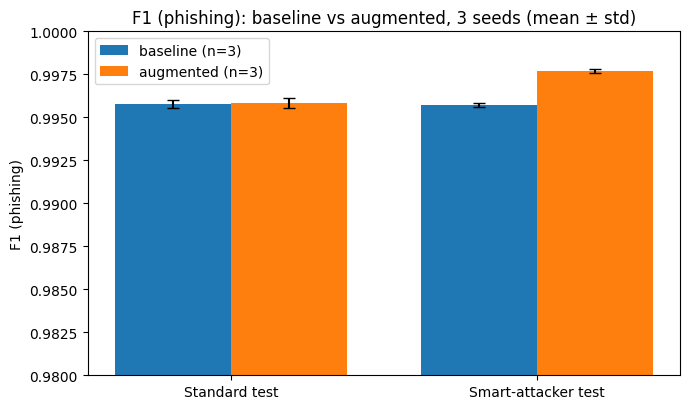

In [14]:
import json, numpy as np, matplotlib.pyplot as plt
agg = json.loads(open('results/aggregated.json').read())
configs = agg['configs']

labels = ['Standard test', 'Smart-attacker test']
x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(7, 4.2))
for i, name in enumerate(['baseline', 'augmented']):
    if name not in configs:
        continue
    c = configs[name]
    means = [c['standard']['f1_phish']['mean'], c['smart_attacker']['f1_phish']['mean']]
    stds  = [c['standard']['f1_phish']['std'],  c['smart_attacker']['f1_phish']['std']]
    ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4, label=f"{name} (n={c['n_seeds']})")

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('F1 (phishing)')
ax.set_ylim(0.98, 1.0)
ax.set_title('F1 (phishing): baseline vs augmented, 3 seeds (mean ± std)')
ax.legend()
plt.tight_layout(); plt.show()

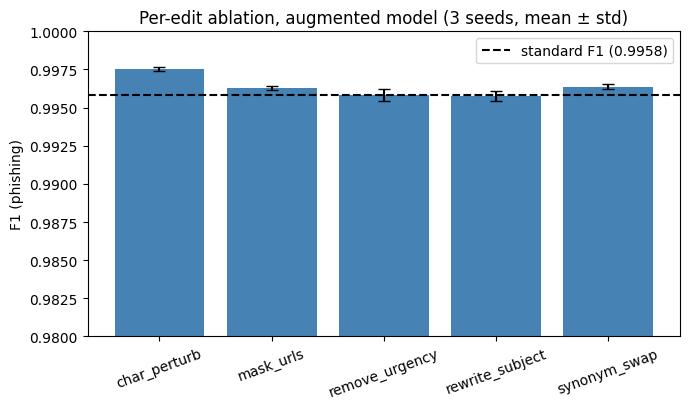

In [15]:
# Per-edit ablation, augmented model, mean ± std
abl = configs['augmented']['ablation']
ops = list(abl.keys())
means = [abl[o]['f1_phish']['mean'] for o in ops]
stds  = [abl[o]['f1_phish']['std']  for o in ops]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(ops, means, yerr=stds, capsize=4, color='steelblue')
std_mean = configs['augmented']['standard']['f1_phish']['mean']
ax.axhline(std_mean, color='black', linestyle='--', label=f'standard F1 ({std_mean:.4f})')
ax.set_ylim(0.98, 1.0)
ax.set_ylabel('F1 (phishing)')
ax.set_title('Per-edit ablation, augmented model (3 seeds, mean ± std)')
plt.xticks(rotation=20); plt.legend(); plt.tight_layout(); plt.show()

## 9. Inspect smart-attacker examples (now includes char_perturb)

In [16]:
from src.augmentation import AugmentationConfig, make_smart_attacker_eval
from src.data_loader import load_splits
splits = load_splits()
smart = make_smart_attacker_eval(splits['test'].head(20).copy(), AugmentationConfig())
for _, row in smart[smart.label == 1].head(3).iterrows():
    print('---')
    print(row['text'][:600])

---
Subject: Psychologist endorsed products for men Smell better with among the girls with a stronger pheromone emitting rod of pleasure. [LINK] -- Use Opera's revolutionary e-mail client: [LINK]
---
Subject: Much bigger, than you used to have it! Success favors only real men with huge-dimensioned rods... Become one of them! Many people have already benefit from our method! You're the next! [LINK] minutes, and Enzo Maresca converted the chance to tieDefending the arrest, President Yoweri Museveni saidmain parties be also elected: Mark Durkan of the SDLP
---
Subject: [Colligate] Casual Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from [LINK] >Top videos and stories as of: Aug 1, 2008 3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= TOP 10 VIDEOS 1. PARIS HILTON TAKES ON MCCAIN [LINK] Paris Hilton swing back at Republican presidential candidate John McCain. Kareen Wynter reports. 2. BIKINI BARISTA STAND CLOSED [LINK] 3. 